# 1. Introduction

This notebook builds a coherent Data -> AI -> Design workflow using a structured earthquake dataset, a disaster tweet dataset, and a local image dataset directory.

This project links data collection, preprocessing, vectorisation, API-driven augmentation, clustering, visualisation, and 3D design mapping into one coherent workflow.

Notebook structure:
2. Data Collection
3. Preprocessing
4. Vectorisation
5. API Interaction
6. Machine Learning
7. Visualisation
8. Data Integration
9. Design Mapping
10. Conclusion

In [1]:
from pathlib import Path
import base64
import json
import re
import warnings

import numpy as np
import pandas as pd
import requests
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
from sentence_transformers import SentenceTransformer

try:
    import torch
    from transformers import CLIPModel, CLIPProcessor
except Exception:
    torch = None
    CLIPModel = None
    CLIPProcessor = None

try:
    import tifffile
except Exception:
    tifffile = None

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
RANDOM_STATE = 42

## 2. Data Collection

The workflow uses three inputs:
- Structured data: Significant Earthquakes, 1965-2016
- Text data: Disaster Tweets
- Image data: Sentinel-2 slum and informal settlement tiles in tif format

This notebook now reads the image dataset from the local archive folder containing Buenos Aires and Cordoba tiles. Files whose names start with vya_ are treated as the positive class.

In [2]:
BASE_DIR = Path.cwd()
EARTHQUAKE_PATH = BASE_DIR / 'Significant Earthquakes, 1965-2016' / 'database.csv'
TRAIN_PATH = BASE_DIR / 'nlp-getting-started' / 'train.csv'
TEST_PATH = BASE_DIR / 'nlp-getting-started' / 'test.csv'
IMAGE_ROOT = BASE_DIR / 'archive'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

SAMPLE_SIZE = 240
OLLAMA_URL = 'http://127.0.0.1:11434/api/generate'
OLLAMA_TEXT_MODEL = 'llama3'
OLLAMA_VISION_MODEL = 'llava'

earthquake_df = pd.read_csv(EARTHQUAKE_PATH)
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

pd.DataFrame({
    'dataset': ['earthquake', 'tweets_train', 'tweets_test', 'archive_tif_images'],
    'records': [len(earthquake_df), len(train_df), len(test_df), len(list(IMAGE_ROOT.rglob('*.tif'))) if IMAGE_ROOT.exists() else 0]
})

,dataset,records
0,earthquake,23412
1,tweets_train,7613
2,tweets_test,3263
3,archive_tif_images,58006


## 3. Preprocessing

The notebook keeps the preprocessing explicit so the final fusion table is traceable and reusable in Blender or TouchDesigner.

In [22]:
def min_max_normalize(series: pd.Series) -> pd.Series:
    series = pd.to_numeric(series, errors='coerce')
    return (series - series.min()) / (series.max() - series.min())

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s#]', ' ', text)
    tokens = [token for token in text.split() if token not in ENGLISH_STOP_WORDS and len(token) > 2]
    return ' '.join(tokens)

eq = earthquake_df.copy()
eq['DateTime'] = pd.to_datetime(eq['Date'] + ' ' + eq['Time'], errors='coerce')
eq['Magnitude'] = pd.to_numeric(eq['Magnitude'], errors='coerce')
eq['Depth'] = pd.to_numeric(eq['Depth'], errors='coerce')
eq['Latitude'] = pd.to_numeric(eq['Latitude'], errors='coerce')
eq['Longitude'] = pd.to_numeric(eq['Longitude'], errors='coerce')
eq = eq.dropna(subset=['DateTime', 'Magnitude', 'Depth', 'Latitude', 'Longitude']).copy()
eq['Place'] = eq.get('Place', eq['ID'].astype(str))
eq['magnitude_norm'] = min_max_normalize(eq['Magnitude'])
eq['depth_norm'] = min_max_normalize(eq['Depth'])
eq['latitude_norm'] = min_max_normalize(eq['Latitude'])
eq['longitude_norm'] = min_max_normalize(eq['Longitude'])
eq = eq.sort_values('DateTime').reset_index(drop=True)

tweets = train_df.copy()
tweets['keyword'] = tweets['keyword'].fillna('unknown')
tweets['location'] = tweets['location'].fillna('unknown')
tweets['text'] = tweets['text'].fillna('')
tweets['text_clean'] = tweets['text'].map(clean_text)
tweets = tweets[tweets['text_clean'].str.len() > 0].reset_index(drop=True)

eq_sample = eq.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).sort_values('DateTime').reset_index(drop=True)
tweet_sample = tweets.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

eq_sample[['DateTime', 'Magnitude', 'Depth', 'magnitude_norm', 'depth_norm']].head()

,DateTime,Magnitude,Depth,magnitude_norm,depth_norm
0,1965-04-27 14:09:10,6.1,60.0,0.166667,0.087149
1,1965-06-11 07:27:44,5.6,35.0,0.027778,0.051491
2,1965-07-29 12:20:21,5.7,15.0,0.055556,0.022964
3,1965-08-11 22:31:51,7.6,30.0,0.583333,0.044359
4,1965-09-01 04:47:33,5.8,100.0,0.083333,0.144202


In [3]:
IMAGE_SUFFIXES = {'.tif', '.tiff'}

def load_image_paths(image_root: Path, limit: int) -> list[Path]:
    if not image_root.exists():
        return []
    all_paths = [path for path in sorted(image_root.rglob('*')) if path.suffix.lower() in IMAGE_SUFFIXES]
    positive_paths = [path for path in all_paths if path.name.lower().startswith('vya_')]
    negative_paths = [path for path in all_paths if not path.name.lower().startswith('vya_')]
    half_limit = limit // 2
    sampled_paths = positive_paths[:half_limit] + negative_paths[: limit - min(len(positive_paths), half_limit)]
    if len(sampled_paths) < limit:
        sampled_paths = all_paths[:limit]
    return sampled_paths[:limit]

def read_tif_as_array(image_path: Path) -> np.ndarray:
    if tifffile is None:
        raise ImportError('tifffile is required to read the tif image dataset.')
    array = tifffile.imread(image_path)
    array = np.asarray(array, dtype=np.float32)
    if array.ndim == 2:
        array = np.expand_dims(array, axis=-1)
    if array.shape[0] in {3, 4} and array.shape[-1] not in {3, 4}:
        array = np.moveaxis(array, 0, -1)
    return array

def normalize_multiband_image(array: np.ndarray) -> np.ndarray:
    array = np.nan_to_num(array, nan=0.0, posinf=0.0, neginf=0.0)
    band_min = array.min(axis=(0, 1), keepdims=True)
    band_max = array.max(axis=(0, 1), keepdims=True)
    scale = np.where((band_max - band_min) == 0, 1.0, band_max - band_min)
    return (array - band_min) / scale

def build_rgb_preview(array: np.ndarray) -> np.ndarray:
    array = normalize_multiband_image(array)
    if array.shape[-1] >= 3:
        rgb = array[:, :, :3]
    else:
        rgb = np.repeat(array[:, :, :1], 3, axis=-1)
    return rgb

def compute_color_histogram(image_path: Path, bins: int = 16) -> np.ndarray:
    array = build_rgb_preview(read_tif_as_array(image_path))
    resized = np.asarray(Image.fromarray((array * 255).astype(np.uint8)).resize((224, 224)), dtype=np.float32) / 255.0
    features = []
    for channel_index in range(3):
        channel_hist, _ = np.histogram(resized[:, :, channel_index], bins=bins, range=(0.0, 1.0), density=True)
        features.extend(channel_hist.tolist())
    return np.asarray(features, dtype=np.float32)

image_paths = load_image_paths(IMAGE_ROOT, SAMPLE_SIZE)

image_features_hist = np.vstack([compute_color_histogram(path) for path in image_paths])
image_df = pd.DataFrame({
    'image_path': [str(path) for path in image_paths],
    'image_available': True,
    'image_label': [1 if path.name.lower().startswith('vya_') else 0 for path in image_paths],
    'image_city': [path.parent.name for path in image_paths]
})

image_df.head()

,image_path,image_available,image_label,image_city
0,c:\Users\dell\Desktop\DM文件夹\6月6\202604月\slackw...,True,1,bs_as
1,c:\Users\dell\Desktop\DM文件夹\6月6\202604月\slackw...,True,1,bs_as
2,c:\Users\dell\Desktop\DM文件夹\6月6\202604月\slackw...,True,1,bs_as
3,c:\Users\dell\Desktop\DM文件夹\6月6\202604月\slackw...,True,1,bs_as
4,c:\Users\dell\Desktop\DM文件夹\6月6\202604月\slackw...,True,1,bs_as


## 4. Vectorisation

Text uses TF-IDF as the baseline and Sentence-BERT as the advanced semantic method.

Images use color histograms as the baseline and CLIP as the advanced semantic method. If CLIP or a local image folder is unavailable, the notebook falls back to the baseline so the rest of the workflow can still run.

In [5]:
tfidf_vectorizer = TfidfVectorizer(max_features=1200, ngram_range=(1, 2))
tfidf_matrix = tfidf_vectorizer.fit_transform(tweet_sample['text_clean'])

sbert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
sbert_embeddings = sbert_model.encode(tweet_sample['text'].tolist(), normalize_embeddings=True, show_progress_bar=False)

def safe_first_match(dataframe: pd.DataFrame, keyword: str, column: str = 'text_clean') -> str:
    matches = dataframe[dataframe[column].str.contains(keyword, na=False)]
    if len(matches) > 0:
        return matches.iloc[0]['text']
    fallback = {
        'collapse': 'The old concrete building may collapse after repeated earthquake damage.',
        'ruin': 'The historic district was left in ruin after the quake and fire.'
    }
    return fallback[keyword]

collapse_sentence = safe_first_match(tweet_sample, 'collapse')
ruin_sentence = safe_first_match(tweet_sample, 'ruin')
comparison_tfidf = TfidfVectorizer().fit_transform([collapse_sentence, ruin_sentence])
comparison_tfidf_score = cosine_similarity(comparison_tfidf[0], comparison_tfidf[1])[0, 0]
comparison_sbert = sbert_model.encode([collapse_sentence, ruin_sentence], normalize_embeddings=True, show_progress_bar=False)
comparison_sbert_score = cosine_similarity([comparison_sbert[0]], [comparison_sbert[1]])[0, 0]

pd.DataFrame({
    'method': ['TF-IDF', 'Sentence-BERT'],
    'cosine_similarity': [comparison_tfidf_score, comparison_sbert_score]
})

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,method,cosine_similarity
0,TF-IDF,0.060222
1,Sentence-BERT,0.069869


In [ ]:
clip_embeddings = None
clip_model_name = 'openai/clip-vit-base-patch32'

def encode_images_with_clip(paths: list[Path]) -> np.ndarray | None:
    if not paths or CLIPModel is None or CLIPProcessor is None or torch is None:
        return None
    try:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        processor = CLIPProcessor.from_pretrained(clip_model_name)
        model = CLIPModel.from_pretrained(clip_model_name).to(device)
    except Exception:
        return None
    embeddings = []
    for path in paths:
        rgb_array = build_rgb_preview(read_tif_as_array(path))
        image = Image.fromarray((rgb_array * 255).astype(np.uint8)).convert('RGB')
        inputs = processor(images=image, return_tensors='pt').to(device)
        with torch.no_grad():
            image_features = model.get_image_features(**inputs)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        embeddings.append(image_features[0].detach().cpu().numpy())
    return np.vstack(embeddings)

clip_embeddings = encode_images_with_clip(image_paths)
image_feature_matrix = clip_embeddings if clip_embeddings is not None else image_features_hist

vectorisation_summary = pd.DataFrame({
    'modality': ['text', 'text', 'image', 'image'],
    'method': ['TF-IDF', 'Sentence-BERT', 'Color Histogram', 'CLIP'],
    'advantages': [
        'Fast and interpretable keyword weighting',
        'Captures context and semantic similarity',
        'Lightweight and easy to compute locally',
        'Cross-modal semantic representation for image-text retrieval'
    ],
    'limitations': [
        'Weak semantic understanding',
        'Requires a pretrained transformer model',
        'Only captures spectral color distribution, not scene meaning',
        'Requires a compatible torch and transformers environment'
    ],
    'used_in_fusion': [False, True, True, clip_embeddings is not None]
})
vectorisation_summary

,modality,method,advantages,limitations,used_in_fusion
0,text,TF-IDF,Fast and interpretable keyword weighting,Weak semantic understanding,False
1,text,Sentence-BERT,Captures context and semantic similarity,Requires a pretrained transformer model,True
2,image,Color Histogram,Lightweight and easy to compute locally,"Only captures spectral color distribution, not...",True
3,image,CLIP,Cross-modal semantic representation for image-...,Requires a compatible torch and transformers e...,False


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


In [7]:
query_terms = ['fear', 'destruction', 'calm']

def top_matches_tfidf(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vector = tfidf_vectorizer.transform([clean_text(query)])
    scores = cosine_similarity(query_vector, tfidf_matrix).ravel()
    top_index = np.argsort(scores)[-top_k:][::-1]
    return tweet_sample.loc[top_index, ['text', 'keyword']].assign(similarity=scores[top_index], query=query).reset_index(drop=True)

def top_matches_sbert(query: str, top_k: int = 5) -> pd.DataFrame:
    query_vector = sbert_model.encode([query], normalize_embeddings=True, show_progress_bar=False)
    scores = cosine_similarity(query_vector, sbert_embeddings).ravel()
    top_index = np.argsort(scores)[-top_k:][::-1]
    return tweet_sample.loc[top_index, ['text', 'keyword']].assign(similarity=scores[top_index], query=query).reset_index(drop=True)

text_similarity_results = {
    'tfidf': {query: top_matches_tfidf(query) for query in query_terms},
    'sbert': {query: top_matches_sbert(query) for query in query_terms}
}

text_similarity_results['sbert']['fear']

,text,keyword,similarity,query
0,Nepal earthquake 3 months on: Women fear abuse...,earthquake,0.316538,fear
1,#ThingsIhate \nWatching someone you care about...,destruction,0.294455,fear
2,New crime: knowing your rights. Punishable by ...,death,0.293053,fear
3,WHITE AMERICANS ARE THE BIGGEST THREAT IN THE ...,threat,0.286113,fear
4,My mama scared of the thunder ????,thunder,0.285278,fear


In [8]:
def top_image_matches_clip(query: str, top_k: int = 5) -> pd.DataFrame:
    if clip_embeddings is None or CLIPModel is None or CLIPProcessor is None or torch is None or not image_paths:
        return pd.DataFrame({
            'query': [query],
            'image_path': ['image_not_available'],
            'similarity': [np.nan]
        })
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    processor = CLIPProcessor.from_pretrained(clip_model_name)
    model = CLIPModel.from_pretrained(clip_model_name).to(device)
    text_inputs = processor(text=[query], return_tensors='pt', padding=True).to(device)
    with torch.no_grad():
        text_features = model.get_text_features(**text_inputs)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    scores = cosine_similarity(text_features.detach().cpu().numpy(), clip_embeddings).ravel()
    top_index = np.argsort(scores)[-top_k:][::-1]
    return pd.DataFrame({
        'query': query,
        'image_path': [str(image_paths[index]) for index in top_index],
        'similarity': scores[top_index]
    })

image_similarity_results = {query: top_image_matches_clip(query) for query in query_terms}
image_similarity_results['destruction']

,query,image_path,similarity
0,destruction,image_not_available,NaN


## 5. API Interaction

This section uses a local Ollama endpoint for structured emotion analysis and optional image captions. If the local model is not available, the notebook falls back to deterministic heuristics so the fusion workflow still completes.

In [9]:
def heuristic_emotion(text: str) -> dict:
    text_lower = text.lower()
    fear_terms = ['fear', 'panic', 'trapped', 'collapse', 'dead', 'destroyed', 'burning', 'evacuation']
    calm_terms = ['safe', 'calm', 'controlled', 'contained', 'stable', 'recover']
    fear_hits = sum(term in text_lower for term in fear_terms)
    calm_hits = sum(term in text_lower for term in calm_terms)
    if fear_hits >= 2:
        return {'emotion': 'panic', 'intensity': 0.9}
    if fear_hits == 1:
        return {'emotion': 'fear', 'intensity': 0.7}
    if calm_hits > 0:
        return {'emotion': 'calm', 'intensity': 0.3}
    return {'emotion': 'chaos', 'intensity': 0.6}

def ollama_json(prompt: str, model: str) -> dict | None:
    payload = {
        'model': model,
        'prompt': prompt,
        'stream': False,
        'format': 'json'
    }
    try:
        response = requests.post(OLLAMA_URL, json=payload, timeout=45)
        response.raise_for_status()
        raw_text = response.json().get('response', '').strip()
        return json.loads(raw_text)
    except Exception:
        return None

def analyze_emotion(text: str) -> dict:
    prompt = (
        'You are a disaster analyst. Analyze the following text and output only JSON with keys emotion and intensity. ' +
        'Allowed emotion values: fear, panic, calm, chaos. Intensity must be between 0.0 and 1.0. Text: ' +
        text
    )
    result = ollama_json(prompt, OLLAMA_TEXT_MODEL)
    if result and 'emotion' in result and 'intensity' in result:
        result['intensity'] = float(np.clip(float(result['intensity']), 0.0, 1.0))
        return result
    return heuristic_emotion(text)

emotion_results = [analyze_emotion(text) for text in tweet_sample['text'].tolist()]
emotion_df = pd.DataFrame(emotion_results).rename(columns={'emotion': 'emotion_label', 'intensity': 'emotion_intensity'})
emotion_df.head()

,emotion_label,emotion_intensity
0,chaos,0.6
1,chaos,0.6
2,chaos,0.6
3,chaos,0.6
4,chaos,0.6


In [26]:
def caption_image(image_path: str) -> str:
    if image_path == 'image_not_available':
        return 'image_not_available'
    prompt = 'Describe this satellite image tile in one short sentence. Output only JSON with one key named caption.'
    try:
        rgb_array = build_rgb_preview(read_tif_as_array(Path(image_path)))
        image_buffer = Image.fromarray((rgb_array * 255).astype(np.uint8)).convert('RGB')
        temp_path = OUTPUT_DIR / 'temp_caption_preview.jpg'
        image_buffer.save(temp_path, format='JPEG')
        encoded_image = base64.b64encode(temp_path.read_bytes()).decode('utf-8')
        payload = {
            'model': OLLAMA_VISION_MODEL,
            'prompt': prompt,
            'stream': False,
            'format': 'json',
            'images': [encoded_image]
        }
        response = requests.post(OLLAMA_URL, json=payload, timeout=60)
        response.raise_for_status()
        result = json.loads(response.json().get('response', '{}'))
        if 'caption' in result:
            return str(result['caption'])
    except Exception:
        pass
    return Path(image_path).stem.replace('_', ' ')

image_df['image_caption'] = image_df['image_path'].map(caption_image)
image_df.head()

,image_path,image_available,image_label,image_city,image_caption
0,c:\Users\dell\Desktop\DM文件夹\6月6\202604月\slackw...,True,1,bs_as,vya T21HUB 1024 1056 4544 4576
1,c:\Users\dell\Desktop\DM文件夹\6月6\202604月\slackw...,True,1,bs_as,vya T21HUB 1120 1152 2304 2336
2,c:\Users\dell\Desktop\DM文件夹\6月6\202604月\slackw...,True,1,bs_as,vya T21HUB 1120 1152 2880 2912
3,c:\Users\dell\Desktop\DM文件夹\6月6\202604月\slackw...,True,1,bs_as,vya T21HUB 1120 1152 2912 2944
4,c:\Users\dell\Desktop\DM文件夹\6月6\202604月\slackw...,True,1,bs_as,vya T21HUB 1120 1152 3680 3712


## 6. Machine Learning

All modalities are aligned by index and fused into one feature table. The final clustering is used as a design driver for scene categories.

In [11]:
def reduce_features(matrix, n_components: int = 8) -> np.ndarray:
    dense_matrix = matrix.toarray() if hasattr(matrix, 'toarray') else matrix
    n_components = min(n_components, dense_matrix.shape[0] - 1, dense_matrix.shape[1])
    if n_components < 1:
        return dense_matrix
    reducer = PCA(n_components=n_components, random_state=RANDOM_STATE)
    return reducer.fit_transform(dense_matrix)

text_features_reduced = reduce_features(sbert_embeddings, n_components=8)
image_features_reduced = reduce_features(image_feature_matrix, n_components=8)
numeric_features = eq_sample[['magnitude_norm', 'depth_norm', 'latitude_norm', 'longitude_norm']].to_numpy()
emotion_features = emotion_df[['emotion_intensity']].to_numpy()

fusion_feature_matrix = np.hstack([
    numeric_features,
    emotion_features,
    text_features_reduced,
    image_features_reduced
])

scaled_fusion_features = StandardScaler().fit_transform(fusion_feature_matrix)
kmeans = KMeans(n_clusters=5, n_init=20, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(scaled_fusion_features)
cluster_projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(scaled_fusion_features)

cluster_df = pd.DataFrame({
    'cluster_id': cluster_labels,
    'cluster_x': cluster_projection[:, 0],
    'cluster_y': cluster_projection[:, 1]
})
cluster_df.head()

,cluster_id,cluster_x,cluster_y
0,3,0.671481,-0.898274
1,0,1.938951,-0.743116
2,3,-0.040219,-0.766994
3,1,0.738589,0.962942
4,3,-0.240069,-1.636654


## 7. Visualisation

Each cell below creates exactly one figure so the analysis remains readable and matches the submission rule of one plot per canvas.

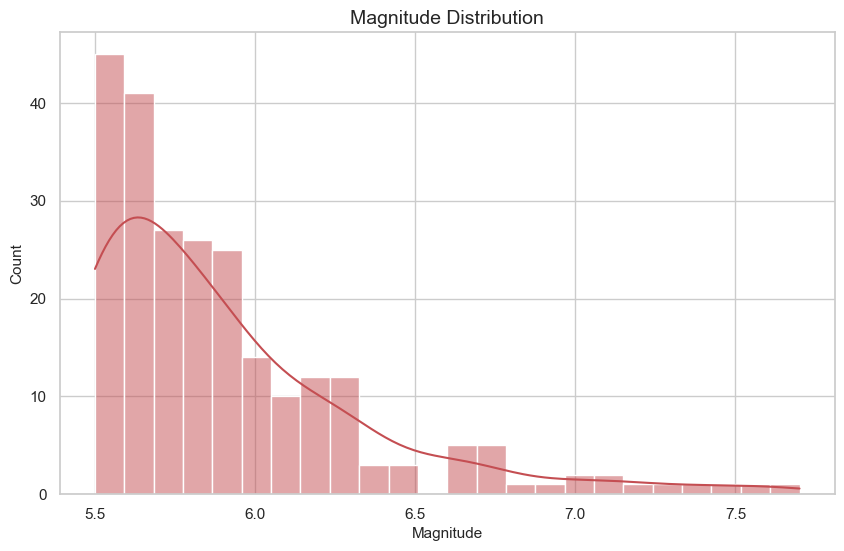

In [ ]:
plt.figure()
sns.histplot(eq_sample['Magnitude'], bins=24, kde=True, color='#c44e52')
plt.title('Magnitude Distribution')
plt.xlabel('Magnitude')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(BASE_DIR / 'magnitude_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

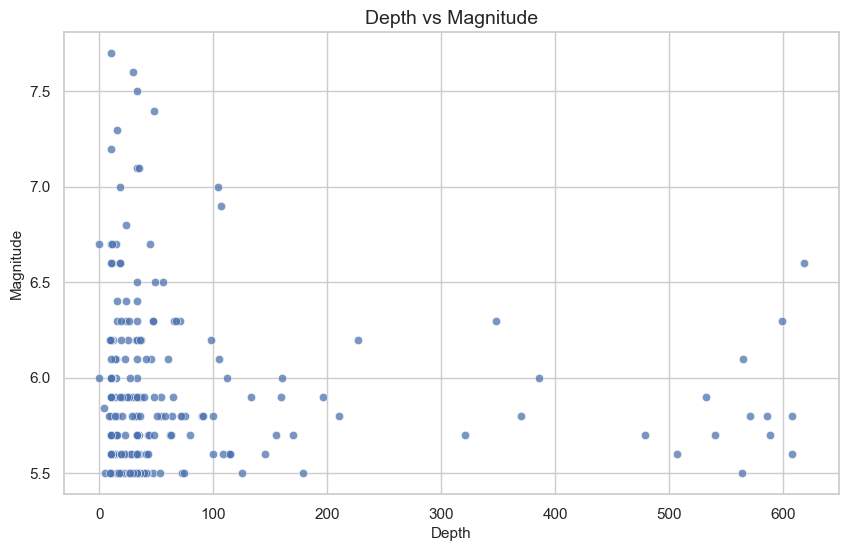

In [ ]:
plt.figure()
sns.scatterplot(data=eq_sample, x='Depth', y='Magnitude', alpha=0.75, color='#4c72b0')
plt.title('Depth vs Magnitude')
plt.xlabel('Depth')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.savefig(BASE_DIR / 'depth_vs_magnitude.png', dpi=300, bbox_inches='tight')
plt.show()

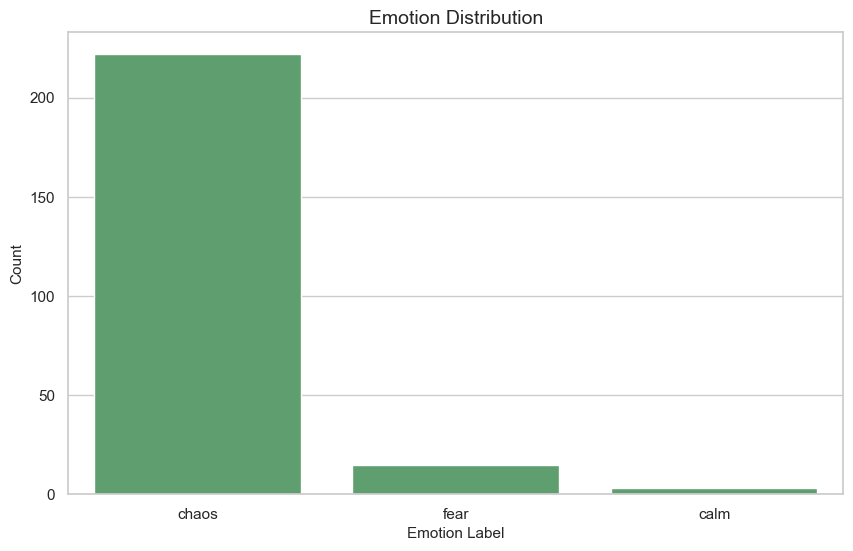

In [ ]:
plt.figure()
sns.countplot(data=emotion_df, x='emotion_label', order=emotion_df['emotion_label'].value_counts().index, color='#55a868')
plt.title('Emotion Distribution')
plt.xlabel('Emotion Label')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(BASE_DIR / 'emotion_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

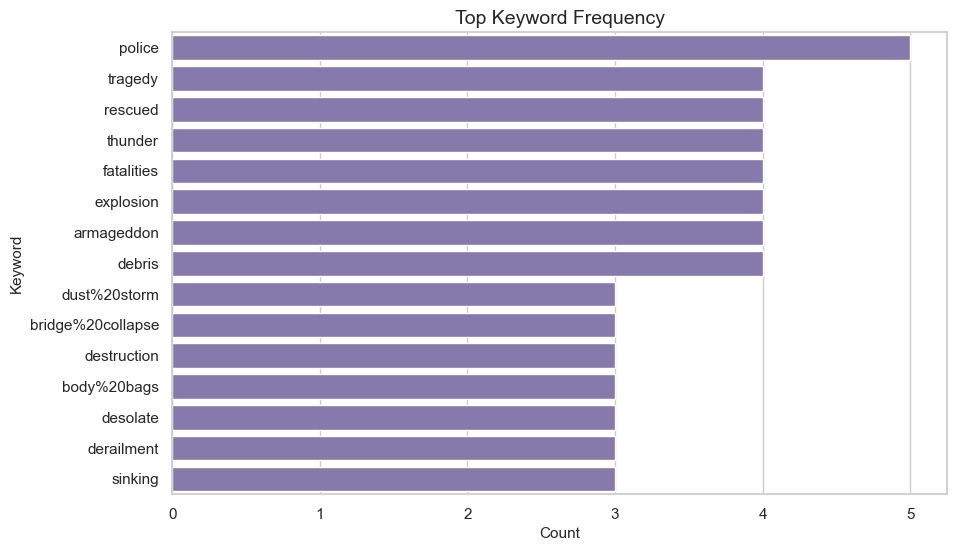

In [ ]:
keyword_counts = tweet_sample['keyword'].replace('unknown', np.nan).dropna().value_counts().head(15).sort_values(ascending=False)
plt.figure()
sns.barplot(x=keyword_counts.values, y=keyword_counts.index, color='#8172b3')
plt.title('Top Keyword Frequency')
plt.xlabel('Count')
plt.ylabel('Keyword')
plt.tight_layout()
plt.savefig(BASE_DIR / 'keyword_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

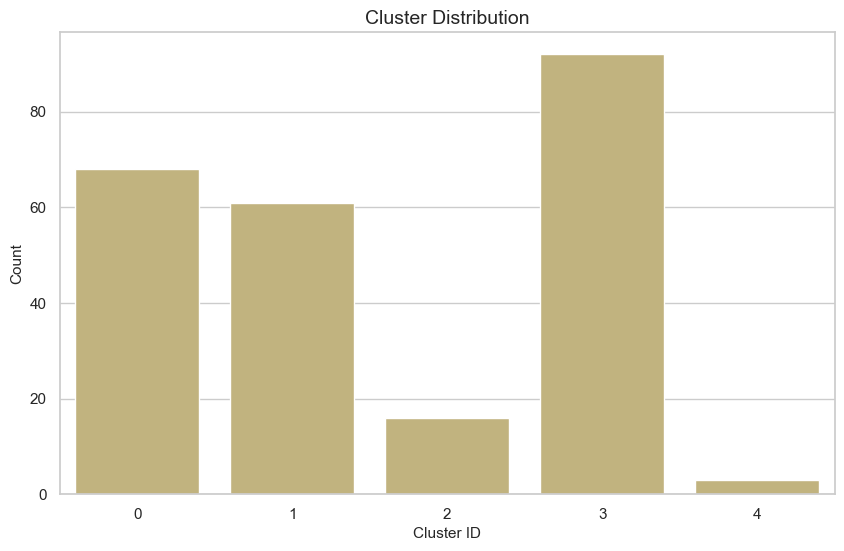

In [ ]:
plt.figure()
sns.countplot(x=cluster_labels, color='#ccb974')
plt.title('Cluster Distribution')
plt.xlabel('Cluster ID')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(BASE_DIR / 'cluster_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

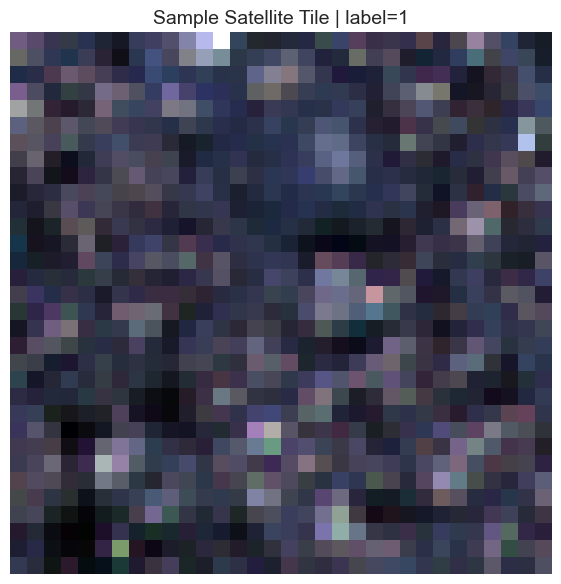

In [4]:
plt.figure()
sample_image_array = build_rgb_preview(read_tif_as_array(image_paths[0]))
plt.imshow(sample_image_array)
plt.title(f"Sample Satellite Tile | label={image_df.loc[0, 'image_label']}")
plt.axis('off')
plt.tight_layout()
plt.savefig(BASE_DIR / 'sample_satellite_tile.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Data Integration

The final dataset merges numerical earthquake features, tweet-based emotion signals, semantic embeddings, image metadata, and cluster labels into one table that can directly drive downstream design logic.

In [28]:
fusion_df = pd.concat([
    eq_sample[['DateTime', 'Place', 'Magnitude', 'Depth', 'magnitude_norm', 'depth_norm', 'Latitude', 'Longitude', 'latitude_norm', 'longitude_norm']].reset_index(drop=True),
    tweet_sample[['id', 'keyword', 'location', 'text', 'text_clean', 'target']].reset_index(drop=True),
    emotion_df.reset_index(drop=True),
    image_df.reset_index(drop=True),
    cluster_df[['cluster_id']].reset_index(drop=True)
], axis=1)

fusion_df['x'] = fusion_df['longitude_norm']
fusion_df['y'] = fusion_df['latitude_norm']
fusion_df['z'] = -fusion_df['depth_norm']
fusion_df['scale'] = 1 + fusion_df['magnitude_norm'] * 4
fusion_df['fragmentation'] = fusion_df['emotion_intensity']
fusion_df['rotation_chaos'] = np.where(fusion_df['emotion_label'].eq('panic'), fusion_df['emotion_intensity'], fusion_df['emotion_intensity'] * 0.4)
fusion_df['material_index'] = fusion_df['cluster_id']
fusion_df['image_density_signal'] = fusion_df['image_label']
fusion_df['city_code'] = fusion_df['image_city'].astype('category').cat.codes

fusion_df.to_csv(OUTPUT_DIR / 'final_fusion_data.csv', index=False)
fusion_df.head()

,DateTime,Place,Magnitude,Depth,magnitude_norm,depth_norm,Latitude,Longitude,latitude_norm,longitude_norm,...,cluster_id,x,y,z,scale,fragmentation,rotation_chaos,material_index,image_density_signal,city_code
0,1965-04-27 14:09:10,ISCGEM858076,6.1,60.0,0.166667,0.087149,35.626,23.425,0.691087,0.565069,...,3,0.565069,0.691087,-0.087149,1.666667,0.6,0.24,3,1,0
1,1965-06-11 07:27:44,ISCGEM856011,5.6,35.0,0.027778,0.051491,44.112,149.539,0.743122,0.915390,...,0,0.915390,0.743122,-0.051491,1.111111,0.6,0.24,0,1,0
2,1965-07-29 12:20:21,ISCGEM855684,5.7,15.0,0.055556,0.022964,50.799,-171.607,0.784125,0.023306,...,3,0.023306,0.784125,-0.022964,1.222222,0.6,0.24,3,1,0
3,1965-08-11 22:31:51,ISCGEM854473,7.6,30.0,0.583333,0.044359,-15.861,167.092,0.375381,0.964150,...,1,0.964150,0.375381,-0.044359,3.333333,0.6,0.24,1,1,0
4,1965-09-01 04:47:33,ISCGEMSUP853515,5.8,100.0,0.083333,0.144202,-34.596,179.922,0.260502,0.999789,...,3,0.999789,0.260502,-0.144202,1.333333,0.6,0.24,3,1,0


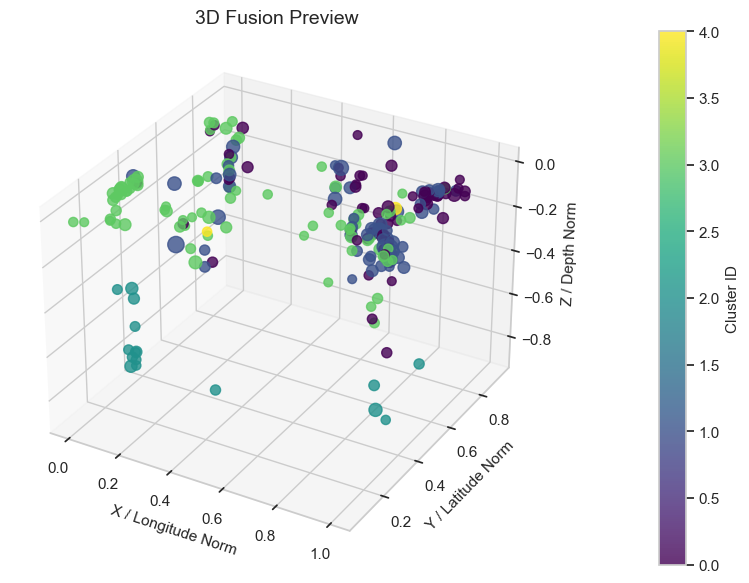

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

plot_df = fusion_df.copy()
plot_df['point_size'] = plot_df['scale'] * 40
plot_df['cluster_color'] = plot_df['cluster_id']

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    plot_df['x'],
    plot_df['y'],
    plot_df['z'],
    c=plot_df['cluster_color'],
    s=plot_df['point_size'],
    cmap='viridis',
    alpha=0.8
)
ax.set_title('3D Fusion Preview')
ax.set_xlabel('X / Longitude Norm')
ax.set_ylabel('Y / Latitude Norm')
ax.set_zlabel('Z / Depth Norm')
fig.colorbar(scatter, ax=ax, pad=0.12, label='Cluster ID')
plt.tight_layout()
plt.savefig(BASE_DIR / 'fusion_3d_preview.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Design Mapping

The table below translates the fused data into direct 3D scene controls.

In [29]:
design_mapping_df = pd.DataFrame({
    'data_variable': ['magnitude_norm', 'depth_norm', 'emotion_intensity', 'emotion_label', 'cluster_id', 'image_density_signal', 'city_code', 'x,y,z'],
    'mapping_rule': [
        'object_scale = 1 + magnitude_norm * 4',
        'z_offset = -depth_norm',
        'noise_strength = emotion_intensity',
        'panic -> higher rotation, calm -> smoother motion, fear -> stronger cracks, chaos -> denser debris',
        'material_index = cluster_id',
        'debris_density = image_density_signal',
        'city_code selects district-specific asset variations',
        'scene_position = normalized longitude, latitude, and depth'
    ],
    'design_effect': [
        'Controls building size or shake amplitude',
        'Pushes objects deeper into the ground plane',
        'Controls terrain fracture and displacement intensity',
        'Switches animation behaviour based on sentiment',
        'Changes material palette or asset family',
        'Increases fragment density for positive slum tiles',
        'Switches between Buenos Aires and Cordoba scene presets',
        'Places fragments in a coherent spatial field'
    ]
})
design_mapping_df.to_csv(OUTPUT_DIR / 'design_mapping_table.csv', index=False)
design_mapping_df

,data_variable,mapping_rule,design_effect
0,magnitude_norm,object_scale = 1 + magnitude_norm * 4,Controls building size or shake amplitude
1,depth_norm,z_offset = -depth_norm,Pushes objects deeper into the ground plane
2,emotion_intensity,noise_strength = emotion_intensity,Controls terrain fracture and displacement int...
3,emotion_label,"panic -> higher rotation, calm -> smoother mot...",Switches animation behaviour based on sentiment
4,cluster_id,material_index = cluster_id,Changes material palette or asset family
5,image_density_signal,debris_density = image_density_signal,Increases fragment density for positive slum t...
6,city_code,city_code selects district-specific asset vari...,Switches between Buenos Aires and Cordoba scen...
7,"x,y,z","scene_position = normalized longitude, latitud...",Places fragments in a coherent spatial field


## 10. Conclusion

This notebook connects structured seismic measurements, public disaster language, and image semantics into one multimodal workflow.

Main outputs:
- final_fusion_data.csv for Blender or TouchDesigner
- design_mapping_table.csv to explain the 3D transformation logic
- similarity analysis that compares baseline and advanced vectorisation methods
- clustering labels that define scene families

Before final submission, add a local image dataset with at least 200 files to the earthquake_images folder so the image branch uses real inputs instead of placeholders.